# Backtesting SMA Crossover Strategy

In [3]:
# === CONFIGURATION ===
initial_capital = 100000
start_date = "2021-01-01"
end_date = "2023-07-25"

stock = "AAPL"

# Moving average lengths (days)
MA1 = 50
MA2 = 200

/var/folders/x6/l7lxx4tx20vdcmk671bzbxs40000gn/T/ipykernel_77049/2947104688.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start=start_date, end=end_date)[['Close']].copy()
[*********************100%***********************]  1 of 1 completed


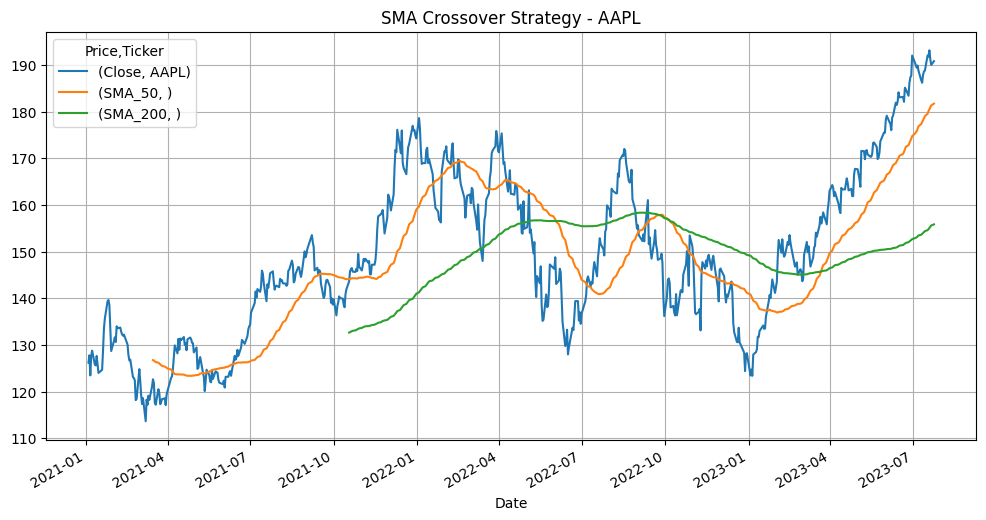

Dates: 2021-01-01 - 2023-07-25
Starting Portfolio Value: $100000
Buy and Hold Final Value: $151,172.16
SMA Crossover Final Value: $113,198.31


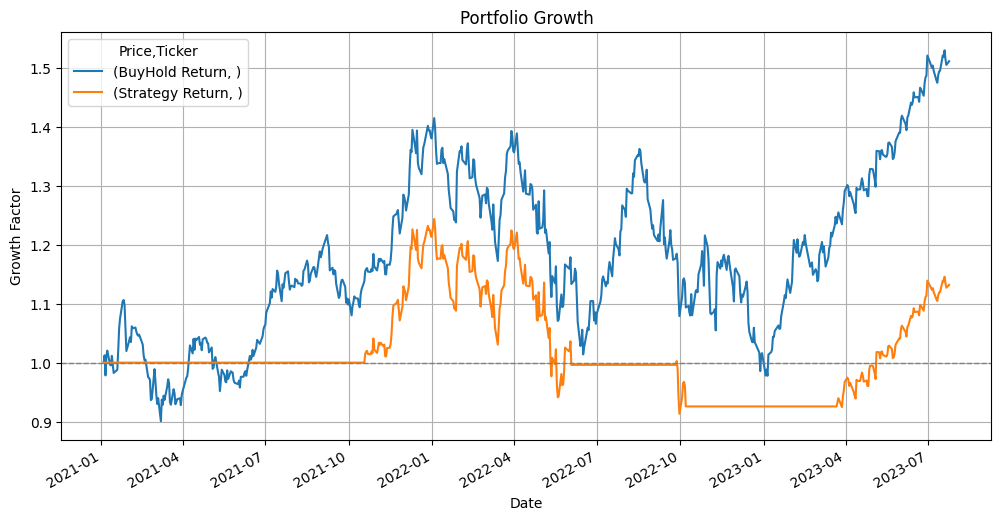

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# === DOWNLOAD DATA ===
df = yf.download(stock, start=start_date, end=end_date)[['Close']].copy()

# === MOVING AVERAGES ===
df[f'SMA_{MA1}'] = df['Close'].rolling(window=MA1).mean()
df[f'SMA_{MA2}'] = df['Close'].rolling(window=MA2).mean()

# === SIGNAL CREATION ===
df['Signal'] = 0
mask = df[f'SMA_{MA2}'].notna()  # only after we have 200 days
df.loc[mask, 'Signal'] = (df.loc[mask, f'SMA_{MA1}'] > df.loc[mask, f'SMA_{MA2}']).astype(int)
df['Position'] = df['Signal'].diff()

# === STRATEGY RETURNS ===
df['Daily Return'] = df['Close'].pct_change().fillna(0)
df['BuyHold Return'] = (1 + df['Daily Return']).cumprod()
df['Strategy Return'] = (1 + df['Daily Return'] * df['Signal'].shift(1).fillna(0)).cumprod()

# === PLOT SMA CROSSOVER ===
df[['Close', f'SMA_{MA1}', f'SMA_{MA2}']].plot(figsize=(12, 6))
plt.title(f"SMA Crossover Strategy - {stock}")
plt.grid(True)
plt.show()

# === FINAL VALUES ===
buy_and_hold_final = initial_capital * df['BuyHold Return'].iloc[-1]
strategy_final = initial_capital * df['Strategy Return'].iloc[-1]

print(f"Dates: {start_date} - {end_date}")
print(f"Starting Portfolio Value: ${initial_capital}")
print(f"Buy and Hold Final Value: ${buy_and_hold_final:,.2f}")
print(f"SMA Crossover Final Value: ${strategy_final:,.2f}")

# === STRATEGY PERFORMANCE PLOT ===
df[['BuyHold Return', 'Strategy Return']].plot(figsize=(12, 6), title="Portfolio Growth")
plt.axhline(1, color='gray', linestyle='--', linewidth=1)
plt.ylabel("Growth Factor")
plt.grid(True)
plt.show()